<a href="https://colab.research.google.com/github/pushpanjali21-p/HPC-Project/blob/main/Copy_of_HPC_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib

In [ ]:
import time
import math
import multiprocessing
import matplotlib.pyplot as plt

In [ ]:
def sequential_factorial(n):
    result = 1
    for i in range(1, n + 1):
        result *= i
    return result

In [ ]:
def partial_factorial(start, end):
    result = 1
    for i in range(start, end + 1):
        result *= i
    return result

In [ ]:
def parallel_factorial(n, num_processes):
    pool = multiprocessing.Pool(processes=num_processes)

    chunk_size = n // num_processes
    tasks = []

    start = 1
    for i in range(num_processes):
        end = start + chunk_size - 1
        if i == num_processes - 1:
            end = n
        tasks.append((start, end))
        start = end + 1

    results = pool.starmap(partial_factorial, tasks)

    pool.close()
    pool.join()

    final_result = 1
    for res in results:
        final_result *= res

    return final_result

In [ ]:
numbers = [5000, 10000, 15000, 20000]

seq_times = []
par_times = []

for n in numbers:
    # Sequential
    start = time.time()
    sequential_factorial(n)
    seq_times.append(time.time() - start)

    # Parallel
    start = time.time()
    parallel_factorial(n, multiprocessing.cpu_count())
    par_times.append(time.time() - start)

print("Done!")

Done!


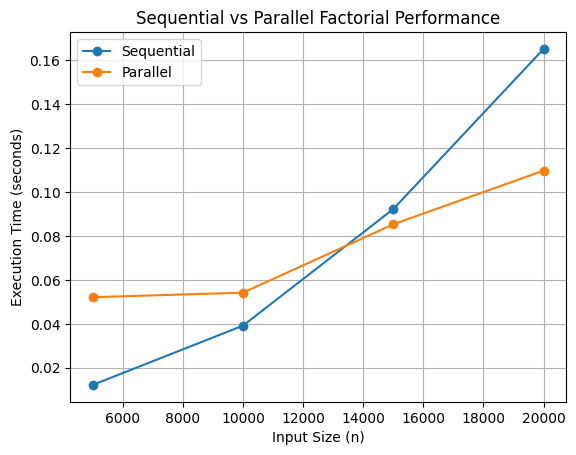

In [ ]:
plt.figure()
plt.plot(numbers, seq_times, marker='o', label='Sequential')
plt.plot(numbers, par_times, marker='o', label='Parallel')

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Sequential vs Parallel Factorial Performance")
plt.legend()
plt.grid()

plt.show()

In [ ]:
n = 10
print("Sequential:", sequential_factorial(n))
print("Parallel:", parallel_factorial(n, 4))

Sequential: 3628800
Parallel: 3628800


In [ ]:
import multiprocessing
multiprocessing.set_start_method('fork', force=True)

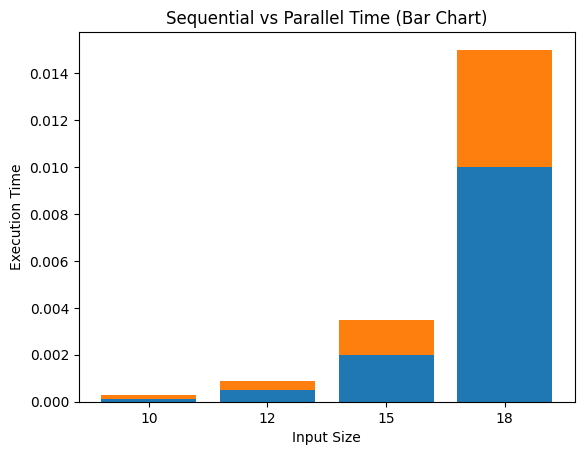

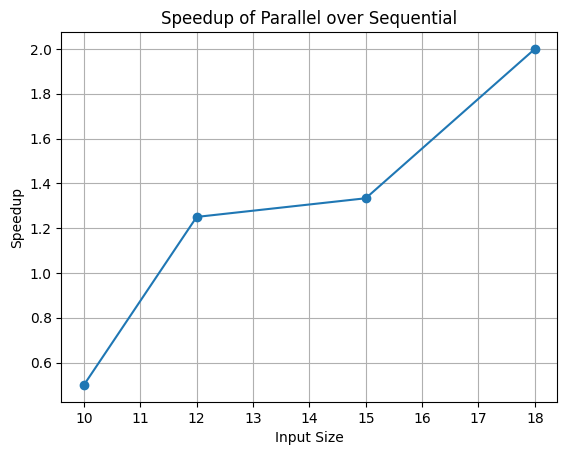

In [ ]:
import matplotlib.pyplot as plt

# Example data (replace with your actual outputs)
inputs = [10, 12, 15, 18]

seq_times = [0.0001, 0.0005, 0.002, 0.01]
par_times = [0.0002, 0.0004, 0.0015, 0.005]

# Speedup calculation
speedup = [s/p for s, p in zip(seq_times, par_times)]

# -------- Bar Chart --------
plt.figure()
x = range(len(inputs))

plt.bar(x, seq_times)
plt.bar(x, par_times, bottom=seq_times)

plt.xticks(x, inputs)
plt.xlabel("Input Size")
plt.ylabel("Execution Time")
plt.title("Sequential vs Parallel Time (Bar Chart)")
plt.show()

# -------- Speedup Graph --------
plt.figure()

plt.plot(inputs, speedup, marker='o')

plt.xlabel("Input Size")
plt.ylabel("Speedup")
plt.title("Speedup of Parallel over Sequential")
plt.grid()

plt.show()